# 2.1 Getting Data

In [3]:
import pandas as pd
import numpy as np

In [4]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
!wget $data   # this line of code simply fetches the file and downloads the file to current directory
                # useful when we want the data locally

--2026-09-29 16:36:24--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.2’

data.csv.2          100%[===================>]   1.41M  --.-KB/s    in 0.1s    

2026-09-29 16:36:26 (12.0 MB/s) - ‘data.csv.2’ saved [1475504/1475504]



# 2.2 Data Preparation

In [5]:
df = pd.read_csv(data)


In [6]:
df.columns = df.columns.str.lower().str.replace(' ', '_' )  # only if we assign the changes to the df.columns then the original data frame and its contents get changed

In [7]:
df.dtypes[df.dtypes =="str"]

make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [8]:
strings = list(df.dtypes[df.dtypes == "str"].index)   # taking the columns which types are string and storing them in the list. Index means column names and values means their types.
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [9]:
for col in strings:    # for converting every records/rows of columns of type string to small case and replacing spaces with _
    df[col] = df[col].str.lower().replace(' ', '_')

df.head(5)    

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1 series m,2011,premium unleaded (required),335.0,6.0,manual,rear wheel drive,2.0,"factory tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1 series,2011,premium unleaded (required),300.0,6.0,manual,rear wheel drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1 series,2011,premium unleaded (required),300.0,6.0,manual,rear wheel drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1 series,2011,premium unleaded (required),230.0,6.0,manual,rear wheel drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1 series,2011,premium unleaded (required),230.0,6.0,manual,rear wheel drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [10]:
df.sample(5)  # used to look random rows of data rather than the same initial rows of data.

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
8264,land rover,range rover evoque,2017,premium unleaded (recommended),240.0,4.0,automatic,all wheel drive,4.0,"crossover,luxury",compact,4dr suv,29,21,258,45800
3864,hyundai,elantra,2016,regular unleaded,145.0,4.0,automatic,front wheel drive,4.0,NaN,compact,sedan,38,28,1439,18250
6867,lincoln,mks,2015,regular unleaded,305.0,6.0,automatic,all wheel drive,4.0,"luxury,performance",large,sedan,26,18,61,40845
1475,ford,aspire,1997,regular unleaded,63.0,4.0,manual,front wheel drive,4.0,hatchback,compact,4dr hatchback,38,29,5657,2000
8879,audi,s5,2016,premium unleaded (required),333.0,6.0,automated_manual,all wheel drive,2.0,"factory tuner,luxury,performance",midsize,coupe,28,18,3105,60350


# 2.3 Exploratory Data Analysis (EDA)

In [11]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:6])
    print(df[col].nunique())

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler', 'nissan']
Length: 6, dtype: str
48
model
<StringArray>
['1 series m', '1 series', '100', '124 spider', '190-class', '2 series']
Length: 6, dtype: str
914
year
[2011 2012 2013 1992 1993 1994]
28
engine_fuel_type
<StringArray>
[   'premium unleaded (required)',               'regular unleaded',
 'premium unleaded (recommended)',       'flex-fuel (unleaded/e85)',
                         'diesel',                       'electric']
Length: 6, dtype: str
10
engine_hp
[335. 300. 230. 320. 172. 160.]
356
engine_cylinders
[ 6.  4.  5.  8. 12.  0.]
9
transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5
driven_wheels
<StringArray>
['rear wheel drive', 'front wheel drive', 'all wheel drive',
 'four wheel drive']
Length: 4, dtype: str
4
number_of_doors
[ 2.  4.  3. nan]
3
market_category
<StringArray>
['factory tuner,luxury,high-performance',
           

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

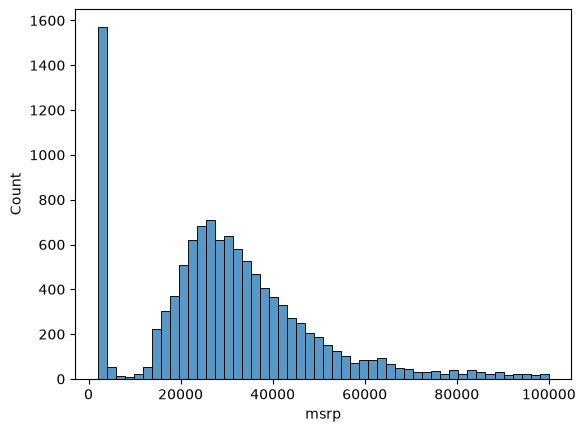

In [13]:
sns.histplot(df.msrp[df.msrp < 100000], bins =50)

In [14]:
price_logs = np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

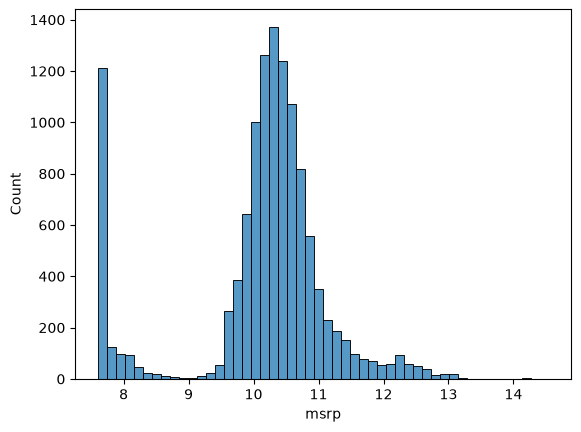

In [15]:
sns.histplot(price_logs, bins = 50)

In [16]:
df.isnull().sum() # finding the toal null values in each of the columns

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# 2.4 setting up the validation framework

In [17]:
# Calcualting the sizes of the parts
# Here we are defining the number or records / data for each phase.
# Splitting into 60/20/20 for train val and test respectively
n = len(df)
n_test = int(n * 0.2)
n_val = int(n * 0.2)
n_train = n - n_test - n_val


n , n_test, n_val, n_train

(11914, 2382, 2382, 7150)

In [18]:
# Taking the part of the data frame of that size
df_val = df.iloc[:n_val]
df_test = df.iloc[n_val:n_val+n_test]
df_train = df.iloc[n_val +n_test:]

In [19]:
# Shuffling the data
np.random.seed(2)
idx = np.arange(n)
np.random.shuffle(idx)
idx

array([2735, 6720, 5878, ..., 6637, 2575, 7336], shape=(11914,))

In [20]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [21]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [22]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [23]:
# delete msrp because we might accidentally use it. If the price gets into the features, we will use the price to predict the price - and of course the model will be perfect
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

# 2.3 Linear Regression

In [24]:
df_train.iloc[10]   # looking a row of data to take the features.

make                                 rolls-royce
model                     phantom drophead coupe
year                                        2015
engine_fuel_type     premium unleaded (required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear wheel drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [25]:
xi = [453, 11, 86]  # we took the feature values of the engine_cylinders, city_mpg and popularity
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [26]:
def linear_regression(xi):
    n = len(xi)
    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

linear_regression(xi)

12.312

In [27]:
np.expm1(12.312)

np.float64(222347.2221101062)

# 2.4 Linear regression vector

In [30]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X =[x1, x2, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [31]:
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [35]:
def linear_regression(X):
    return X.dot(w_new)

In [38]:
y = linear_regression(X)

In [39]:
np.exp(y)

array([237993.82334859, 768349.51018973, 222348.22211011])